## Optimization: Backpropagation

## Overview
In this exercise we will use backpropagation to train a multi-layer perceptron (with a single hidden layer).  We will experiment with different patterns and see how quickly or slowly the weights converge.  We will see the impact and interplay of different parameters such as learning rate, number of iterations, and number of data points.

Shape of Full X Matrix is: (500, 3)
Shape of Y is: (500,)


/tmp/ipykernel_2563/3548831007.py:20: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "ro" (-> color='r'). The keyword argument will take precedence.
  ax.plot(x_matrix_full[y==1, 0], x_matrix_full[y==1, 1], 'ro', label='Class 1', color='darkslateblue')
/tmp/ipykernel_2563/3548831007.py:21: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "bx" (-> color='b'). The keyword argument will take precedence.
  ax.plot(x_matrix_full[y==0, 0], x_matrix_full[y==0, 1], 'bx', label='Class 0', color='chocolate')


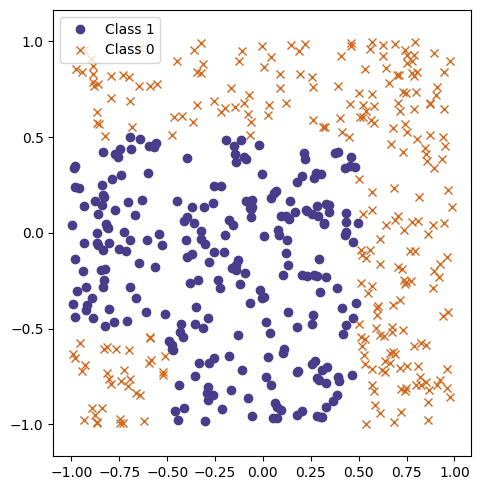

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

observations = 500
x_matrix = np.random.uniform(-1, 1, size= (observations, 2))
x_matrix_bias = np.ones((observations, 1))
x_matrix_full = np.concatenate((x_matrix, x_matrix_bias), axis=1)

circle_pattern = (np.sqrt(x_matrix_full[:,0]**2 + x_matrix_full[:,1]**2)<.75).astype(int)
diamond_pattern = ((np.abs(x_matrix_full[:,0]) + np.abs(x_matrix_full[:,1]))<1).astype(int)
centered_square = ((np.maximum(np.abs(x_matrix_full[:,0]), np.abs(x_matrix_full[:,1])))<.5).astype(int)

y = (((np.maximum((x_matrix_full[:,0]), (x_matrix_full[:,1])))<.5) & ((np.maximum((x_matrix_full[:,0]), (x_matrix_full[:,1])))>-.5)).astype(int)
thin_ra = (((np.maximum((x_matrix_full[:,0]), (x_matrix_full[:,1])))<.5) & ((np.maximum((x_matrix_full[:,0]), (x_matrix_full[:,1])))>0)).astype(int)

print('Shape of Full X Matrix is: {}'.format(x_matrix_full.shape))
print('Shape of Y is: {}'.format(y.shape))

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(x_matrix_full[y==1, 0], x_matrix_full[y==1, 1], 'ro', label='Class 1', color='darkslateblue')
ax.plot(x_matrix_full[y==0, 0], x_matrix_full[y==0, 1], 'bx', label='Class 0', color='chocolate')
ax.legend(loc='best')
ax.axis('equal')
plt.tight_layout()

## Helper Functions

In [ ]:
# sigmoid activation function
def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))

def forward_pass(W1, W2):

    global x_mat, y, num_

    # compute the predictions
    z_2 = np.dot(x_mat, W1)
    a_2 = sigmoid(z_2)
    z_3 = np.dot(a_2, W2)
    y_hat = sigmoid(z_3).reshape((len(x_mat), ))

    # compute the gradient
    J_z_3_grad = -y + y_hat
    J_W_2_grad = np.dot(J_z_3_grad, a_2)
    a_2_z_2_grad = sigmoid(z_2) * (1 - sigmoid(z_2))
    J_W_1_grad = (np.dot((J_z_3_grad).reshape(-1, 1), W2.reshape(-1, 1).T) * a_2_z_2_grad).T.dot(x_mat).T
    gradient = (J_W_1_grad, J_W_2_grad)

    return y_hat, gradient

def plot_loss_accuracy(loss_vals, accuracies):
    fig = plt.figure(figsize=(16, 8))
    fig.suptitle('Log Loss and Accuracy over iterations')
    
    ax = fig.add_subplot(1, 2, 1)
    ax.plot(loss_vals)
    ax.grid(True)
    ax.set(xlabel='iterations', title='Log Loss')
    
    ax = fig.add_subplot(1, 2, 2)
    ax.plot(accuracies)
    ax.grid(True)
    ax.set(xlabel='iterations', title='Accuracy')

# loss function
def loss_fn(y_true, y_pred, epsilon=1e-16):
    y_pred = np.maximum(y_pred, epsilon)
    y_pred = np.minimum(y_pred, (1 - epsilon))
    return -(np.sum(y_true * np.log(y_pred)) + np.sum((1 - y_true) * np.log(1 - y_pred))) / len(y_true)

In [ ]:
# init network params